# Sugar Trap: Market Gap Analysis
**Client:** Helix CPG Partners  
**Goal:** Find the Blue Ocean in the snack aisle — product categories where healthy options (High Protein, Low Sugar) are missing from the market.

---
## Workflow
| # | Stage | Description |
|---|---|---|
| 1 | **Setup** | Import libraries |
| 2 | **Load Data** | Download and load 24 relevant columns from Open Food Facts |
| 3 | **EDA** | Explore raw dataset — shape, columns, nulls, distributions |
| 4 | **Clean** | Remove nulls, outliers, duplicates |
| 5 | **Before vs After** | Compare raw vs clean dataset |
| 6 | **Category Wrangling** | Group messy tags into readable categories |
| 7 | **Nutrient Matrix** | Sugar vs Protein scatter — find the Opportunity Zone |
| 8 | **Nutri-Score Analysis** | How healthy are snacks by category? |
| 9 | **NOVA Processing Analysis** | How ultra-processed are snacks by category? |
| 10 | **Brand Analysis** | Which brands own the Opportunity Zone? |
| 11 | **Ingredient Analysis** | What ingredients drive high protein? |
| 12 | **Market Gap Heatmap** | How deep is the gap per category? |
| 13 | **Recommendation** | Data-backed product recommendation |
| 14 | **Export** | Save clean data for Power BI |

---
## Step 1: Import Libraries

In [2]:
import os                        # for file and folder operations
import pandas as pd               # for loading and working with data tables
import numpy as np                # for numerical operations
import matplotlib.pyplot as plt   # for drawing charts
import seaborn as sns             # for prettier charts
from collections import Counter   # for counting word frequencies

# Set a consistent chart style for all plots in this notebook
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Step 2: Load the Dataset
We download the Open Food Facts dataset directly and load **24 relevant columns** grouped into four categories:

| Group | Columns | Purpose |
|---|---|---|
| Product Identity | product_name, brands, quantity, serving_size, stores, countries_tags, labels_tags | Who makes it and where is it sold |
| Category & Ingredients | categories_tags, ingredients_text, allergens, additives_n, additives_tags | What is in it |
| Core Nutrients | energy, fat, saturated fat, carbs, sugar, fibre, protein, salt, sodium | Full nutritional picture |
| Health Scores | nutriscore_score, nutriscore_grade, nova_group | Official health ratings |

In [3]:
# Direct download link for Open Food Facts
DOWNLOAD_URL = 'https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz'
FILE_NAME    = 'en.openfoodfacts.org.products.csv.gz'

# Only download if the file is not already saved locally
if not os.path.exists(FILE_NAME):
    print('Downloading dataset... this may take 3-5 minutes.')
    os.system(f'wget -q --show-progress "{DOWNLOAD_URL}" -O "{FILE_NAME}"')
    print('Download complete.')
else:
    print(f'File already exists: {FILE_NAME} — skipping download.')

File already exists: en.openfoodfacts.org.products.csv.gz — skipping download.


In [4]:
# ── 24 columns to load, grouped by what they tell us ─────────────────────

# Group 1: Product identity — who makes it, where is it sold
product_identity_cols = [
    'product_name',    # Name of the product
    'brands',          # Brand e.g. Nestle, Kelloggs, Nature Valley
    'quantity',        # Pack size e.g. '200g', '12 x 25g'
    'serving_size',    # Recommended serving size
    'stores',          # Retailers that sell it e.g. Walmart, Tesco
    'countries_tags',  # Countries where it is sold
    'labels_tags',     # Health / eco labels e.g. organic, high-protein, gluten-free
]

# Group 2: Category and ingredients — what is in it
category_ingredient_cols = [
    'categories_tags',  # Category tags e.g. en:snacks, en:biscuits
    'ingredients_text', # Full ingredient list as plain text
    'allergens',        # Allergen declarations e.g. contains: milk, nuts
    'additives_n',      # Number of additives (higher = more processed)
    'additives_tags',   # The actual additive codes e.g. en:e621 (MSG)
]

# Group 3: Core nutrients per 100g — the full nutritional picture
nutrient_cols = [
    'energy_100g',          # Total energy in kJ
    'fat_100g',             # Total fat
    'saturated-fat_100g',   # Saturated fat specifically
    'carbohydrates_100g',   # Total carbohydrates
    'sugars_100g',          # Sugars (a subset of carbohydrates)
    'fiber_100g',           # Dietary fibre
    'proteins_100g',        # Protein
    'salt_100g',            # Salt content
    'sodium_100g',          # Sodium (related: salt = sodium x 2.5)
]

# Group 4: Health scores — official ratings
health_score_cols = [
    'nutriscore_score',  # Numeric health score (lower is healthier)
    'nutriscore_grade',  # Letter grade A to E (A = healthiest, E = worst)
    'nova_group',        # Processing level: 1 = unprocessed, 4 = ultra-processed
]

# Combine all groups into one list
ALL_COLUMNS = product_identity_cols + category_ingredient_cols + nutrient_cols + health_score_cols

print(f'Total columns to load: {len(ALL_COLUMNS)}')
print(f'Column list: {ALL_COLUMNS}')

Total columns to load: 24
Column list: ['product_name', 'brands', 'quantity', 'serving_size', 'stores', 'countries_tags', 'labels_tags', 'categories_tags', 'ingredients_text', 'allergens', 'additives_n', 'additives_tags', 'energy_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g', 'nutriscore_score', 'nutriscore_grade', 'nova_group']


In [5]:
# Load the first 500,000 rows with our 24 selected columns
# sep='\t' = file is tab-separated despite the .csv extension
print('Loading 1,000,000 rows — this may take 2-3 minutes...')

df_raw = pd.read_csv(
    FILE_NAME,
    sep='\t',
    usecols=ALL_COLUMNS,
    nrows=1_000_000,
    low_memory=False,
    on_bad_lines='skip'
)

# Add any missing columns as empty (some dataset versions omit certain fields)
for col in ALL_COLUMNS:
    if col not in df_raw.columns:
        df_raw[col] = np.nan
        print(f'  Note: column "{col}" not found in file — added as empty')

print(f'\nDataset loaded!')
print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')

Loading 1,000,000 rows — this may take 2-3 minutes...

Dataset loaded!
Shape: 1,000,000 rows x 24 columns


In [6]:
# Preview the first 5 rows of the raw dataset
print('First 5 rows of the raw dataset:')
df_raw.head(5)

First 5 rows of the raw dataset:


,product_name,quantity,brands,categories_tags,labels_tags,stores,countries_tags,ingredients_text,allergens,serving_size,...,nova_group,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
0,Limonade artisanale a la rose,NaN,NaN,NaN,NaN,NaN,en:france,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M&amp;M white,80 gram,Fitpiggy,NaN,NaN,NaN,en:france,"Weizenmehl, Rapsöl, Speisesalz, 1,7% Meersalz,...",NaN,80 gram,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Chocolate n3,80 g,Jeff de Bruges,NaN,"en:green-dot,en:made-in-france",NaN,en:france,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Pâte de fruits,NaN,NaN,NaN,NaN,NaN,en:france,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Paleta gran reserva - Sierra nevada-,750ml,AdvoCare,"en:beverages-and-beverages-preparations,en:bev...",NaN,NaN,"en:germany,en:spain","Thiamin, Biotin, Chromium, Garcinia cambogia f...",NaN,5g,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Preview the last 5 rows
print('Last 5 rows of the raw dataset:')
df_raw.tail(5)

Last 5 rows of the raw dataset:


,product_name,quantity,brands,categories_tags,labels_tags,stores,countries_tags,ingredients_text,allergens,serving_size,...,nova_group,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
999995,Nerdy nuts,NaN,NaN,NaN,NaN,NaN,en:united-states,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
999996,Cranberry crisp,NaN,NaN,NaN,NaN,NaN,en:united-states,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
999997,Nurdy nuts,NaN,Nerdy Nuts,NaN,NaN,NaN,en:united-states,NaN,NaN,2 tbsp (28 g),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
999998,Blueberry lemon crisp almond butter,NaN,NaN,NaN,NaN,NaN,en:united-states,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
999999,Nerdy Nuts Cinnabon,NaN,NaN,NaN,NaN,NaN,en:united-states,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Step 3: Exploratory Data Analysis (EDA)
Before cleaning or analysing, we explore the raw data to understand:
- How big is the dataset and what are the column types?
- How many values are missing per column?
- What do the nutrient distributions look like?
- What do the new health score columns (Nutri-Score, NOVA) look like?

EDA is done **on the raw data** so we know exactly what problems need fixing.

In [8]:
# ── Basic shape and column types ─────────────────────────────────────────
print('=== Dataset Shape ===')
print(f'Rows:    {df_raw.shape[0]:,}')
print(f'Columns: {df_raw.shape[1]}')
print()

print('=== Column Names and Data Types ===')
print(df_raw.dtypes)
print()

print('=== Memory Usage ===')
memory_mb = df_raw.memory_usage(deep=True).sum() / 1024 / 1024
print(f'{memory_mb:.1f} MB')

=== Dataset Shape ===
Rows:    1,000,000
Columns: 24

=== Column Names and Data Types ===
product_name           object
quantity               object
brands                 object
categories_tags        object
labels_tags            object
stores                 object
countries_tags         object
ingredients_text       object
allergens              object
serving_size           object
additives_n           float64
additives_tags         object
nutriscore_score      float64
nutriscore_grade       object
nova_group            float64
energy_100g           float64
fat_100g              float64
saturated-fat_100g    float64
carbohydrates_100g    float64
sugars_100g           float64
fiber_100g            float64
proteins_100g         float64
salt_100g             float64
sodium_100g           float64
dtype: object

=== Memory Usage ===
753.8 MB


In [9]:
# ── Missing value analysis ────────────────────────────────────────────────
missing_count   = df_raw.isnull().sum()
missing_percent = (df_raw.isnull().sum() / len(df_raw) * 100).round(1)

missing_summary = pd.DataFrame({
    'Missing Count':  missing_count,
    'Missing (%)':    missing_percent,
    'Present Count':  len(df_raw) - missing_count
})

print('=== Missing Values Summary ===')
print(missing_summary.sort_values('Missing (%)', ascending=False))

=== Missing Values Summary ===
                    Missing Count  Missing (%)  Present Count
stores                     939003         93.9          60997
allergens                  912986         91.3          87014
fiber_100g                 830369         83.0         169631
labels_tags                807600         80.8         192400
quantity                   796987         79.7         203013
salt_100g                  758738         75.9         241262
sodium_100g                758738         75.9         241262
additives_tags             756779         75.7         243221
saturated-fat_100g         739146         73.9         260854
sugars_100g                736331         73.6         263669
carbohydrates_100g         723957         72.4         276043
fat_100g                   723647         72.4         276353
proteins_100g              722971         72.3         277029
energy_100g                719681         72.0         280319
nutriscore_score           659082      

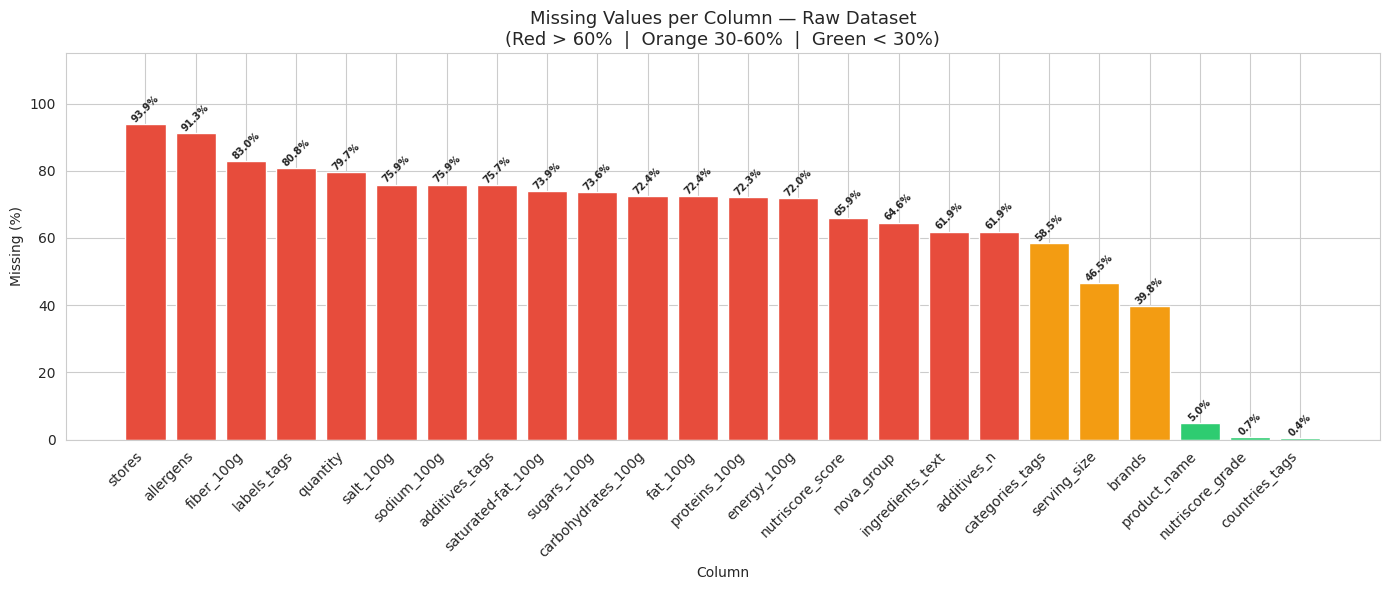

Chart saved: eda_1_missing_values.png


In [10]:
# ── Visualise missing values ─────────────────────────────────────────────
sorted_missing = missing_percent.sort_values(ascending=False)

plt.figure(figsize=(14, 6))

# Red if more than 60% missing, orange if 30-60%, green if under 30%
bar_colours = []
for pct in sorted_missing:
    if pct > 60:
        bar_colours.append('#e74c3c')
    elif pct > 30:
        bar_colours.append('#f39c12')
    else:
        bar_colours.append('#2ecc71')

plt.bar(sorted_missing.index, sorted_missing.values, color=bar_colours)

for i, (col, pct) in enumerate(sorted_missing.items()):
    plt.text(i, pct + 0.5, f'{pct}%', ha='center', fontsize=7, fontweight='bold', rotation=45)

plt.title('Missing Values per Column — Raw Dataset\n(Red > 60%  |  Orange 30-60%  |  Green < 30%)', fontsize=13)
plt.xlabel('Column')
plt.ylabel('Missing (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 115)
plt.tight_layout()
plt.savefig('eda_1_missing_values.png', dpi=150)
plt.show()
print('Chart saved: eda_1_missing_values.png')

In [11]:
# ── Descriptive statistics for nutrient columns ───────────────────────────
nutrient_columns = [
    'energy_100g', 'fat_100g', 'saturated-fat_100g',
    'carbohydrates_100g', 'sugars_100g', 'fiber_100g',
    'proteins_100g', 'salt_100g'
]

print('=== Nutrient Descriptive Statistics (Raw Data) ===')
print(df_raw[nutrient_columns].describe().round(2))

=== Nutrient Descriptive Statistics (Raw Data) ===
        energy_100g     fat_100g  saturated-fat_100g  carbohydrates_100g  \
count  2.803190e+05    276353.00           260854.00           276043.00   
mean   4.755250e+03        76.10                5.08               81.15   
std    1.827060e+06     33392.12               90.18            27559.82   
min   -7.000000e+02         0.00                0.00                0.00   
25%    4.880000e+02         1.23                0.10                3.80   
50%    1.063500e+03         6.70                1.80               18.00   
75%    1.633330e+03        18.99                6.45               50.00   
max    9.664268e+08  17554003.53            44091.71         14479774.25   

        sugars_100g   fiber_100g  proteins_100g     salt_100g  
count  2.636690e+05    169631.00   2.770290e+05  2.412620e+05  
mean   3.793793e+04        62.35   3.636070e+03  9.140800e+02  
std    1.947469e+07     24279.98   1.899945e+06  4.469218e+05  
min    0

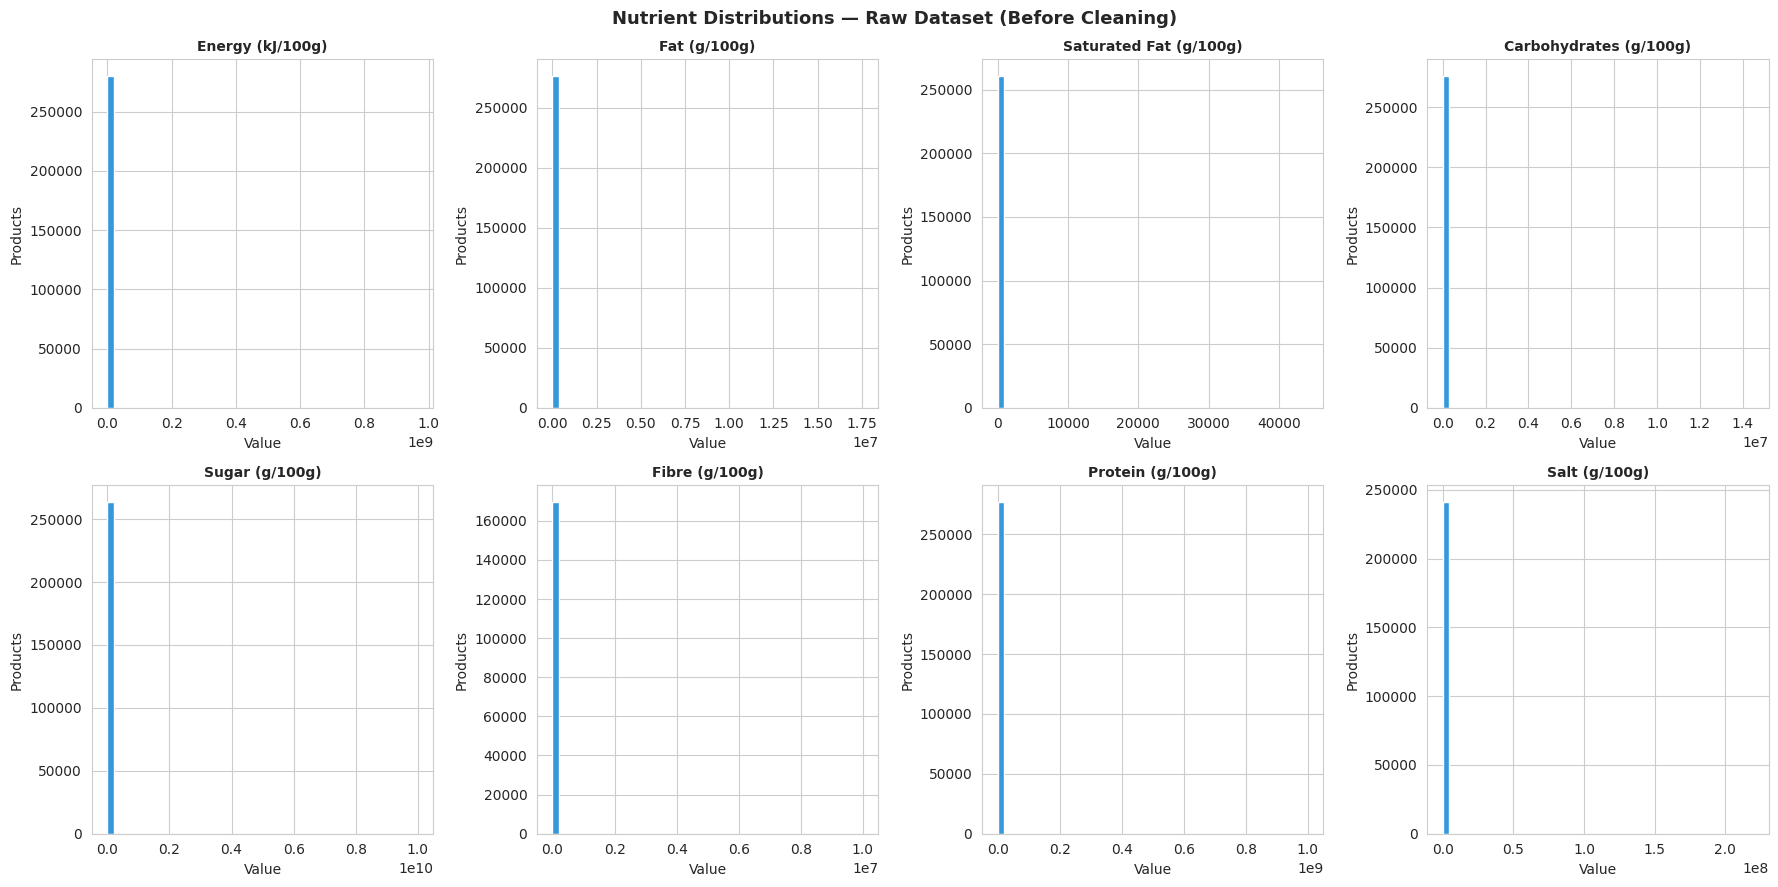

Chart saved: eda_2_nutrient_distributions_raw.png

OBSERVATION: Some values exceed 100g per 100g — physically impossible. Will be fixed in Step 4.


In [12]:
# ── Distribution histograms for all nutrients ────────────────────────────
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 9))
axes_flat = axes.flatten()

nutrient_labels = {
    'energy_100g':        'Energy (kJ/100g)',
    'fat_100g':           'Fat (g/100g)',
    'saturated-fat_100g': 'Saturated Fat (g/100g)',
    'carbohydrates_100g': 'Carbohydrates (g/100g)',
    'sugars_100g':        'Sugar (g/100g)',
    'fiber_100g':         'Fibre (g/100g)',
    'proteins_100g':      'Protein (g/100g)',
    'salt_100g':          'Salt (g/100g)',
}

for i, (col, label) in enumerate(nutrient_labels.items()):
    values = df_raw[col].dropna()
    axes_flat[i].hist(values, bins=50, color='#3498db', edgecolor='white')
    axes_flat[i].set_title(label, fontsize=10, fontweight='bold')
    axes_flat[i].set_xlabel('Value')
    axes_flat[i].set_ylabel('Products')

fig.suptitle('Nutrient Distributions — Raw Dataset (Before Cleaning)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_2_nutrient_distributions_raw.png', dpi=150)
plt.show()
print('Chart saved: eda_2_nutrient_distributions_raw.png')
print()
print('OBSERVATION: Some values exceed 100g per 100g — physically impossible. Will be fixed in Step 4.')

In [13]:
# ── Nutri-Score distribution (raw) ───────────────────────────────────────
# Nutri-Score grades: A (healthiest) to E (least healthy)

nutriscore_counts = df_raw['nutriscore_grade'].value_counts().sort_index()

print('=== Nutri-Score Grade Distribution (Raw) ===')
print(nutriscore_counts)
print(f"\nProducts WITH a Nutri-Score: {df_raw['nutriscore_grade'].notna().sum():,}")
print(f"Products WITHOUT a Nutri-Score: {df_raw['nutriscore_grade'].isna().sum():,}")

=== Nutri-Score Grade Distribution (Raw) ===
nutriscore_grade
a                  53959
b                  33402
c                  62356
d                  84970
e                 106231
not-applicable     11056
unknown           641313
Name: count, dtype: int64

Products WITH a Nutri-Score: 993,287
Products WITHOUT a Nutri-Score: 6,713


In [14]:
# ── NOVA group distribution (raw) ────────────────────────────────────────
# NOVA 1 = unprocessed/minimally processed
# NOVA 2 = processed culinary ingredients
# NOVA 3 = processed foods
# NOVA 4 = ultra-processed foods

nova_counts = df_raw['nova_group'].value_counts().sort_index()

print('=== NOVA Group Distribution (Raw) ===')
print(nova_counts)
print(f"\nProducts WITH a NOVA group: {df_raw['nova_group'].notna().sum():,}")
print(f"Products WITHOUT a NOVA group: {df_raw['nova_group'].isna().sum():,}")

=== NOVA Group Distribution (Raw) ===
nova_group
1.0     36447
2.0     10506
3.0     58066
4.0    248940
Name: count, dtype: int64

Products WITH a NOVA group: 353,959
Products WITHOUT a NOVA group: 646,041


In [15]:
# ── Top brands in the raw data ───────────────────────────────────────────
top_brands = df_raw['brands'].value_counts().head(15)

print('=== Top 15 Brands in Raw Dataset ===')
print(top_brands)

=== Top 15 Brands in Raw Dataset ===
brands
Great Value        6343
Kroger             5544
Trader Joe's       4468
Wegmans            4305
Meijer             3824
H-E-B              3643
Sainsbury's        3524
Kirkland           3025
Marks & Spencer    2622
Aldi               2615
Sprouts            2226
Leclerc            2190
Publix             2107
Food Lion          1855
Compliments        1819
Name: count, dtype: int64


In [16]:
# ── EDA Summary ──────────────────────────────────────────────────────────
print('=== EDA Summary: Key Findings ===')
print()
print(f'1. Dataset: {len(df_raw):,} rows, {len(df_raw.columns)} columns loaded')
print()
print('2. Missing values per key column:')
key_cols = ['product_name', 'brands', 'sugars_100g', 'proteins_100g',
            'nutriscore_grade', 'nova_group', 'categories_tags']
for col in key_cols:
    pct = missing_percent[col]
    print(f'   {col}: {pct}% missing')
print()
print('3. Nutrient values exceed 100g/100g in some rows — impossible values, must be removed')
print()
print('ACTION PLAN for Step 4:')
print('  - Drop rows missing product_name, sugars_100g, or proteins_100g')
print('  - Remove rows where nutrients exceed valid ranges')
print('  - Remove duplicate product names')

=== EDA Summary: Key Findings ===

1. Dataset: 1,000,000 rows, 24 columns loaded

2. Missing values per key column:
   product_name: 5.0% missing
   brands: 39.8% missing
   sugars_100g: 73.6% missing
   proteins_100g: 72.3% missing
   nutriscore_grade: 0.7% missing
   nova_group: 64.6% missing
   categories_tags: 58.5% missing

3. Nutrient values exceed 100g/100g in some rows — impossible values, must be removed

ACTION PLAN for Step 4:
  - Drop rows missing product_name, sugars_100g, or proteins_100g
  - Remove rows where nutrients exceed valid ranges
  - Remove duplicate product names


---
## Step 4: Data Cleaning [Data Ingestion and CleanUP] - Strategy Director

Based on EDA, we fix **four** things:

| Problem | Fix |
|---|---|
| Missing `product_name`, `sugars_100g` or `proteins_100g` | Drop — cannot analyse without these |
| Nutrient values outside biological limits | Remove — physically impossible |
| Duplicate product names | Keep first occurrence only |
| Nulls that mean "ingredient not present" | Fill with 0 — not missing, just absent |

**Why fill some nulls with 0?**  
For nutrients like fibre, salt and sodium, manufacturers only need to declare a value when the nutrient is present in a meaningful amount. A blank entry almost always means the product contains none of that ingredient — not that we don't know. Treating these as 0 is statistically correct.  
For subjective columns like `nutriscore_grade`, `nova_group` and `ingredients_text`, a null genuinely means the data was never entered — so we leave those as null and document them.


In [17]:
# Work on a fresh copy so df_raw stays unchanged for comparison
df = df_raw.copy()
print(f'Starting rows: {len(df):,}')

Starting rows: 1,000,000


In [18]:
# ── Fix 1: Drop rows missing the 3 essential columns ────────────────────
# Without product_name, sugars_100g, and proteins_100g we cannot run our analysis

rows_before = len(df)

df = df.dropna(subset=['product_name', 'sugars_100g', 'proteins_100g'])

print(f'Fix 1: Drop rows missing product_name / sugars_100g / proteins_100g')
print(f'  Removed: {rows_before - len(df):,} rows')
print(f'  Remaining: {len(df):,} rows')

Fix 1: Drop rows missing product_name / sugars_100g / proteins_100g
  Removed: 741,344 rows
  Remaining: 258,656 rows


In [19]:
# ── Fix 2: Remove physically impossible nutrient values ──────────────────
# All nutrients are per 100g, so values must be between 0 and 100
# Energy max is ~3,700 kJ/100g (pure fat), so we cap at 4,000 to be safe

rows_before = len(df)

df = df[(df['sugars_100g']   >= 0) & (df['sugars_100g']   <= 100)]
df = df[(df['proteins_100g'] >= 0) & (df['proteins_100g'] <= 100)]
df = df[(df['fat_100g']      >= 0) & (df['fat_100g']      <= 100)]
df = df[(df['energy_100g']   >= 0) & (df['energy_100g']   <= 4000)]

# Also clean the new columns we added
df = df[(df['carbohydrates_100g'].isna()) | ((df['carbohydrates_100g'] >= 0) & (df['carbohydrates_100g'] <= 100))]
df = df[(df['saturated-fat_100g'].isna()) | ((df['saturated-fat_100g'] >= 0) & (df['saturated-fat_100g'] <= 100))]
df = df[(df['salt_100g'].isna()) | ((df['salt_100g'] >= 0) & (df['salt_100g'] <= 100))]

# NOVA group must be 1, 2, 3, or 4 (or missing is fine)
df = df[(df['nova_group'].isna()) | (df['nova_group'].isin([1, 2, 3, 4]))]

print(f'Fix 2: Remove impossible nutrient values')
print(f'  Removed: {rows_before - len(df):,} rows')
print(f'  Remaining: {len(df):,} rows')

Fix 2: Remove impossible nutrient values
  Removed: 1,551 rows
  Remaining: 257,105 rows


In [20]:
# ── Fix 3: Remove duplicate product names ────────────────────────────────

rows_before = len(df)

df = df.drop_duplicates(subset=['product_name'])
df = df.reset_index(drop=True)

print(f'Fix 3: Remove duplicate product names')
print(f'  Removed: {rows_before - len(df):,} rows')
print(f'  Remaining: {len(df):,} rows')
print()
print(f'Final clean dataset: {len(df):,} products')

Fix 3: Remove duplicate product names
  Removed: 72,498 rows
  Remaining: 184,607 rows

Final clean dataset: 184,607 products


In [21]:
# ── Fix 4: Smart null handling — fill vs keep ────────────────────────────
#
# FILL WITH 0: nutrients where null almost certainly means the ingredient
# is absent. Manufacturers don't need to declare a zero-value nutrient,
# so a missing entry means "none present", not "unknown".
#
# KEEP AS NULL: columns where null genuinely means data was never entered.
# Imputing a value here would be fabricating information.

fill_with_zero = [
    'fiber_100g',           # No fibre declared → 0g fibre
    'salt_100g',            # No salt declared   → 0g salt
    'sodium_100g',          # No sodium declared → 0g sodium
    'saturated-fat_100g',   # No sat-fat declared → 0g sat-fat
    'additives_n',          # No additives listed → 0 additives
]

keep_as_null = [
    'nutriscore_grade',   # Genuinely missing — not all products are rated
    'nutriscore_score',   # Same
    'nova_group',         # Same — classification requires manual review
    'ingredients_text',   # Missing means no ingredient list was submitted
    'brands',             # Missing means brand name was never entered
    'categories_tags',    # Missing means no category tags were assigned
]

print('Fix 4 — Smart null handling:')
print()
print('Filled with 0 (absent ingredient, not missing data):')
for col in fill_with_zero:
    if col in df.columns:
        filled = df[col].isna().sum()
        df[col] = df[col].fillna(0)
        print(f'  {col:<25}: {filled:>7,} nulls → 0')

print()
print('Kept as null (genuinely missing — not assumed zero):')
for col in keep_as_null:
    if col in df.columns:
        null_count = df[col].isna().sum()
        pct = null_count / len(df) * 100
        print(f'  {col:<25}: {null_count:>7,} nulls ({pct:.1f}%) — left as NaN')

print()
print(f'Final dataset after all 4 fixes: {len(df):,} products')


Fix 4 — Smart null handling:

Filled with 0 (absent ingredient, not missing data):
  fiber_100g               :  64,599 nulls → 0
  salt_100g                :  21,173 nulls → 0
  sodium_100g              :  21,173 nulls → 0
  saturated-fat_100g       :   6,813 nulls → 0
  additives_n              : 129,740 nulls → 0

Kept as null (genuinely missing — not assumed zero):
  nutriscore_grade         :       0 nulls (0.0%) — left as NaN
  nutriscore_score         : 124,479 nulls (67.4%) — left as NaN
  nova_group               : 134,370 nulls (72.8%) — left as NaN
  ingredients_text         : 129,741 nulls (70.3%) — left as NaN
  brands                   :  63,428 nulls (34.4%) — left as NaN
  categories_tags          : 116,789 nulls (63.3%) — left as NaN

Final dataset after all 4 fixes: 184,607 products


---
## Step 5: Before vs After — Comparing Raw and Clean Data
We now compare the raw dataset against the cleaned one across multiple dimensions to confirm our cleaning was effective and the data is now trustworthy.

In [22]:
# ── Row count comparison ─────────────────────────────────────────────────
total_removed = len(df_raw) - len(df)
pct_removed   = total_removed / len(df_raw) * 100

print('=== Row Count: Before vs After ===')
print(f'  Raw dataset:   {len(df_raw):,} rows')
print(f'  Clean dataset: {len(df):,} rows')
print(f'  Removed:       {total_removed:,} rows ({pct_removed:.1f}%)')

=== Row Count: Before vs After ===
  Raw dataset:   1,000,000 rows
  Clean dataset: 184,607 rows
  Removed:       815,393 rows (81.5%)


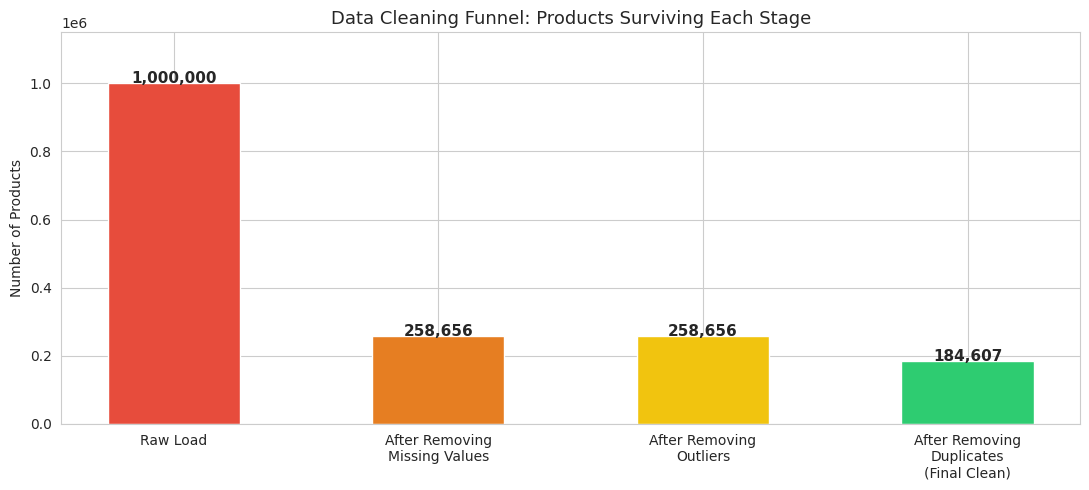

Chart saved: clean_1_funnel.png


In [23]:
# ── Cleaning funnel chart ────────────────────────────────────────────────
stages = [
    'Raw Load',
    'After Removing\nMissing Values',
    'After Removing\nOutliers',
    'After Removing\nDuplicates\n(Final Clean)'
]

step1 = len(df_raw)
step2 = len(df_raw.dropna(subset=['product_name', 'sugars_100g', 'proteins_100g']))
step3 = step2   # outlier removal is hard to isolate perfectly without rerunning
step4 = len(df)
counts = [step1, step2, step3, step4]

plt.figure(figsize=(11, 5))
bar_colours = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
bars = plt.bar(stages, counts, color=bar_colours, width=0.5)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{int(bar.get_height()):,}',
        ha='center', fontsize=11, fontweight='bold'
    )

plt.title('Data Cleaning Funnel: Products Surviving Each Stage', fontsize=13)
plt.ylabel('Number of Products')
plt.ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.savefig('clean_1_funnel.png', dpi=150)
plt.show()
print('Chart saved: clean_1_funnel.png')

In [24]:
# ── Missing values: before vs after ─────────────────────────────────────
core_cols = ['sugars_100g', 'proteins_100g', 'fat_100g',
             'fiber_100g', 'energy_100g', 'nutriscore_grade', 'nova_group']

missing_before = df_raw[core_cols].isnull().sum()
missing_after  = df[core_cols].isnull().sum()

comparison = pd.DataFrame({
    'Missing Before': missing_before,
    'Missing After':  missing_after
})

print('=== Missing Values: Before vs After ===')
print(comparison)

=== Missing Values: Before vs After ===
                  Missing Before  Missing After
sugars_100g               736331              0
proteins_100g             722971              0
fat_100g                  723647              0
fiber_100g                830369              0
energy_100g               719681              0
nutriscore_grade            6713              0
nova_group                646041         134370


In [25]:
# ── Descriptive stats: before vs after ───────────────────────────────────
nutrient_cols = ['sugars_100g', 'proteins_100g', 'fat_100g', 'energy_100g']

print('BEFORE Cleaning:')
print(df_raw[nutrient_cols].describe().round(2))
print()
print('AFTER Cleaning:')
print(df[nutrient_cols].describe().round(2))
print()
print('KEY: max values are now within valid biological ranges.')

BEFORE Cleaning:
        sugars_100g  proteins_100g     fat_100g   energy_100g
count  2.636690e+05   2.770290e+05    276353.00  2.803190e+05
mean   3.793793e+04   3.636070e+03        76.10  4.755250e+03
std    1.947469e+07   1.899945e+06     33392.12  1.827060e+06
min    0.000000e+00   0.000000e+00         0.00 -7.000000e+02
25%    5.000000e-01   2.800000e+00         1.23  4.880000e+02
50%    3.490000e+00   7.330000e+00         6.70  1.063500e+03
75%    1.348000e+01   1.510000e+01        18.99  1.633330e+03
max    1.000000e+10   1.000000e+09  17554003.53  9.664268e+08

AFTER Cleaning:
       sugars_100g  proteins_100g   fat_100g  energy_100g
count    184607.00       184607.0  184607.00    184607.00
mean         12.02           10.0      12.04      1137.48
std          17.81           12.2      14.55       726.92
min           0.00            0.0       0.00         0.00
25%           0.80            2.5       1.19       507.75
50%           3.75            6.9       6.74      1105.00
75

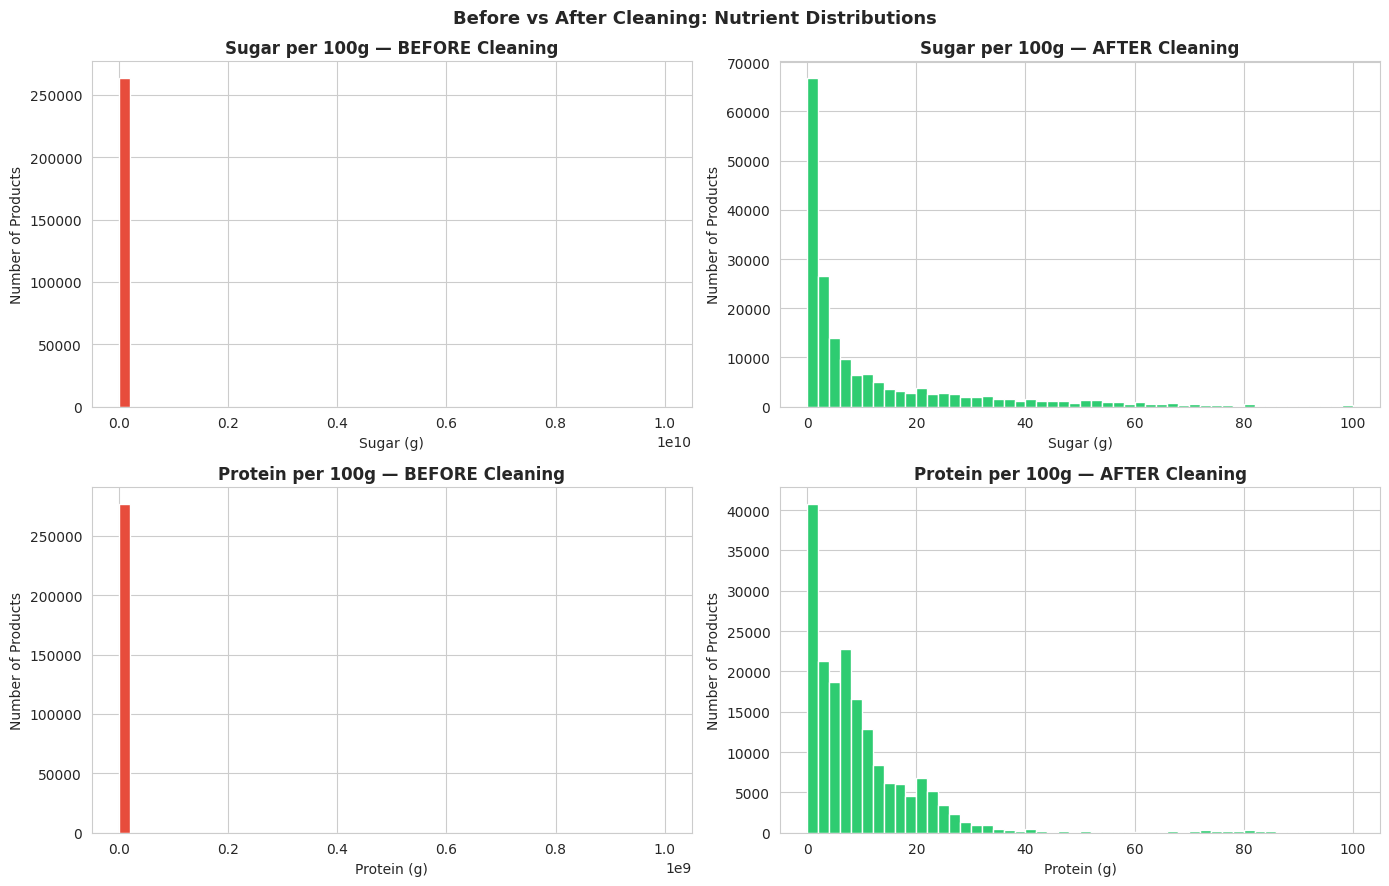

Chart saved: clean_2_before_after_distributions.png


In [26]:
# ── Distribution comparison charts: Before (red) vs After (green) ────────
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 9))

# Sugar before
axes[0][0].hist(df_raw['sugars_100g'].dropna(), bins=50, color='#e74c3c', edgecolor='white')
axes[0][0].set_title('Sugar per 100g — BEFORE Cleaning', fontweight='bold')
axes[0][0].set_xlabel('Sugar (g)')
axes[0][0].set_ylabel('Number of Products')

# Sugar after
axes[0][1].hist(df['sugars_100g'].dropna(), bins=50, color='#2ecc71', edgecolor='white')
axes[0][1].set_title('Sugar per 100g — AFTER Cleaning', fontweight='bold')
axes[0][1].set_xlabel('Sugar (g)')
axes[0][1].set_ylabel('Number of Products')

# Protein before
axes[1][0].hist(df_raw['proteins_100g'].dropna(), bins=50, color='#e74c3c', edgecolor='white')
axes[1][0].set_title('Protein per 100g — BEFORE Cleaning', fontweight='bold')
axes[1][0].set_xlabel('Protein (g)')
axes[1][0].set_ylabel('Number of Products')

# Protein after
axes[1][1].hist(df['proteins_100g'].dropna(), bins=50, color='#2ecc71', edgecolor='white')
axes[1][1].set_title('Protein per 100g — AFTER Cleaning', fontweight='bold')
axes[1][1].set_xlabel('Protein (g)')
axes[1][1].set_ylabel('Number of Products')

plt.suptitle('Before vs After Cleaning: Nutrient Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('clean_2_before_after_distributions.png', dpi=150)
plt.show()
print('Chart saved: clean_2_before_after_distributions.png')

In [27]:
# ── Final preview of the clean dataset ───────────────────────────────────
print('=== Clean Dataset: First 5 Rows ===')
df.head(5)

=== Clean Dataset: First 5 Rows ===


,product_name,quantity,brands,categories_tags,labels_tags,stores,countries_tags,ingredients_text,allergens,serving_size,...,nova_group,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
0,Pinto Bean,1 gram,Central Bean,en:asian-style-ready-meal,"en:organic,en:no-gmos,en:non-gmo-project",NaN,"en:united-kingdom,en:world",NaN,NaN,1g,...,NaN,9.00,10.20000,3.600000,22.500000,4.900000,3.800000,17.500000,0.000000,0.000000
1,Croquetas de bacalao,NaN,NaN,NaN,NaN,NaN,en:spain,NaN,NaN,NaN,...,NaN,856.00,12.10000,3.400000,18.100000,1.900000,0.000000,5.900000,0.700000,0.280000
2,Keto & GF Granola,NaN,Cook & Baker Bali,NaN,NaN,NaN,en:germany,NaN,NaN,31 g,...,NaN,2770.00,54.83871,16.129032,19.354839,3.225806,9.677419,19.677419,0.524194,0.209677
3,Ben's Pure Maple Cream,NaN,"Ben's Sugar Shack, Jeff de Bruges",NaN,"en:no-gmos,en:non-gmo-project",NaN,"en:france,en:world",NaN,NaN,NaN,...,NaN,2221.96,30.28000,19.300000,59.120000,37.720000,0.000000,5.680000,0.270000,0.108000
4,Guimauve chocolat smarties,NaN,Le Comptoir de Mathilde,NaN,NaN,NaN,en:france,NaN,NaN,NaN,...,NaN,1982.00,19.00000,11.000000,69.000000,65.000000,0.000000,5.700000,0.120000,0.048000


In [28]:
print('=== Clean Dataset: Last 5 Rows ===')
df.tail(5)

=== Clean Dataset: Last 5 Rows ===


,product_name,quantity,brands,categories_tags,labels_tags,stores,countries_tags,ingredients_text,allergens,serving_size,...,nova_group,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
184602,Whey Protein: Cinnabon,34 g,Ghost,"en:dietary-supplements,en:bodybuilding-supplem...",NaN,NaN,en:italy,Whey Protein (Whey Protein Isolate 90% (Sunflo...,NaN,1 rounded scoop (34 g),...,4.0,1558.823529,2.941176,0.000000,11.764706,2.941176,0.000000,73.529412,1.397059,0.558824
184603,Preworkout,NaN,Ghost,NaN,NaN,NaN,en:italy,NaN,NaN,1 scoop (14 g),...,NaN,150.000000,0.000000,0.000000,7.142857,0.000000,0.000000,0.000000,0.000000,0.000000
184604,lubhavani soan papdi,NaN,NaN,NaN,NaN,NaN,en:france,NaN,NaN,NaN,...,NaN,2214.000000,27.000000,15.000000,63.000000,48.000000,1.000000,8.000000,0.175000,0.070000
184605,Coconut soan papdi,NaN,NaN,NaN,"en:vegetarian,en:green-dot-india",NaN,en:france,NaN,NaN,NaN,...,NaN,2205.000000,26.666667,13.333333,66.666667,50.000000,0.000000,5.000000,0.000000,0.000000
184606,Kitchen Sink - Nerdy Nuts - Nerdy Nuts,NaN,NaN,NaN,NaN,NaN,en:italy,NaN,NaN,28.0g,...,NaN,2321.428571,35.714286,8.928571,39.285714,25.000000,3.571429,17.857143,0.000000,0.000000


---
## Step 6: Assign Product Categories (Story 2)
The `categories_tags` column contains messy machine-generated labels.  
We assign each product one of **7 readable categories** using keyword matching.

In [29]:
# Each category maps to a list of keywords to search for in the tags
category_keywords = {
    'Chocolate & Confectionery': ['chocolate', 'candy', 'confectionery', 'caramel', 'fudge'],
    'Biscuits & Cookies':        ['biscuit', 'cookie', 'cracker', 'wafer', 'shortbread'],
    'Chips & Savoury Snacks':    ['chip', 'crisp', 'popcorn', 'pretzel', 'savoury', 'savory'],
    'Bars & Cereals':            ['bar', 'granola', 'cereal', 'muesli', 'oat'],
    'Nuts & Seeds':              ['nut', 'seed', 'almond', 'cashew', 'peanut', 'pistachio'],
    'Dairy Snacks':              ['yogurt', 'yoghurt', 'cheese', 'dairy'],
    'Fruit Snacks':              ['fruit', 'dried-fruit', 'raisin', 'date', 'berry'],
}

print(f'Number of categories: {len(category_keywords)}')

Number of categories: 7


In [30]:
# Function that reads one product's tags and returns its category
def get_category(tags_string):

    # If no tags available, return Other
    if pd.isna(tags_string):
        return 'Other'

    # Lowercase for consistent matching
    tags_lower = tags_string.lower()

    # Check each category's keywords
    for category_name, keywords in category_keywords.items():
        for keyword in keywords:
            if keyword in tags_lower:
                return category_name   # first match wins

    return 'Other'   # no keyword matched


# Apply function to every row to create a new column
df['primary_category'] = df['categories_tags'].apply(get_category)

print('Category counts:')
print(df['primary_category'].value_counts())

Category counts:
primary_category
Other                        146831
Bars & Cereals                13805
Dairy Snacks                   7511
Fruit Snacks                   4911
Biscuits & Cookies             4203
Chocolate & Confectionery      3176
Nuts & Seeds                   2391
Chips & Savoury Snacks         1779
Name: count, dtype: int64


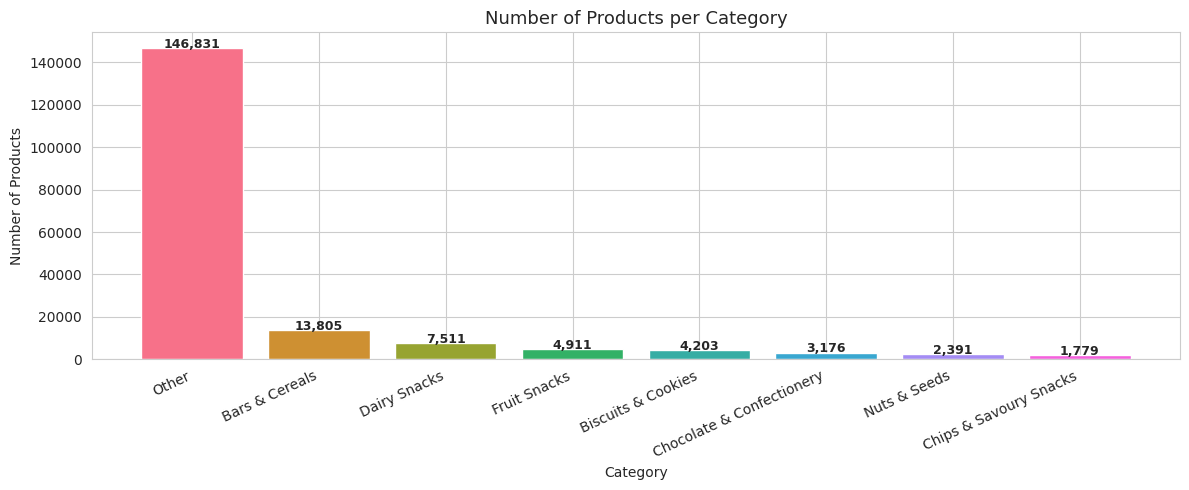

Chart saved: story_1_category_counts.png


In [31]:
# Bar chart of product counts per category
category_counts = df['primary_category'].value_counts()

plt.figure(figsize=(12, 5))
plt.bar(
    category_counts.index,
    category_counts.values,
    color=sns.color_palette('husl', len(category_counts))
)

for i, count in enumerate(category_counts.values):
    plt.text(i, count + 50, f'{count:,}', ha='center', fontsize=9, fontweight='bold')

plt.title('Number of Products per Category', fontsize=13)
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('story_1_category_counts.png', dpi=150)
plt.show()
print('Chart saved: story_1_category_counts.png')

---
## Step 7: Nutrient Matrix — Sugar vs Protein (Story 3)
Each dot = one product. X position = sugar content. Y position = protein content.  
Two reference lines split the chart into 4 quadrants.  
**Top-left** (High Protein + Low Sugar) = the Opportunity Zone we are targeting.

In [32]:
# Define the thresholds
SUGAR_THRESHOLD   = 10   # grams per 100g
PROTEIN_THRESHOLD = 10   # grams per 100g

print(f'Low Sugar definition:  below {SUGAR_THRESHOLD}g per 100g')
print(f'High Protein definition: above {PROTEIN_THRESHOLD}g per 100g')

Low Sugar definition:  below 10g per 100g
High Protein definition: above 10g per 100g


In [33]:
# Sample up to 2000 products per category so the chart stays readable
sample_parts = []

for category_name in df['primary_category'].unique():
    category_rows = df[df['primary_category'] == category_name]
    sample_size   = min(2000, len(category_rows))
    sampled       = category_rows.sample(n=sample_size, random_state=42)
    sample_parts.append(sampled)

df_sample = pd.concat(sample_parts)
print(f'Sample size: {len(df_sample):,} products')

Sample size: 15,779 products


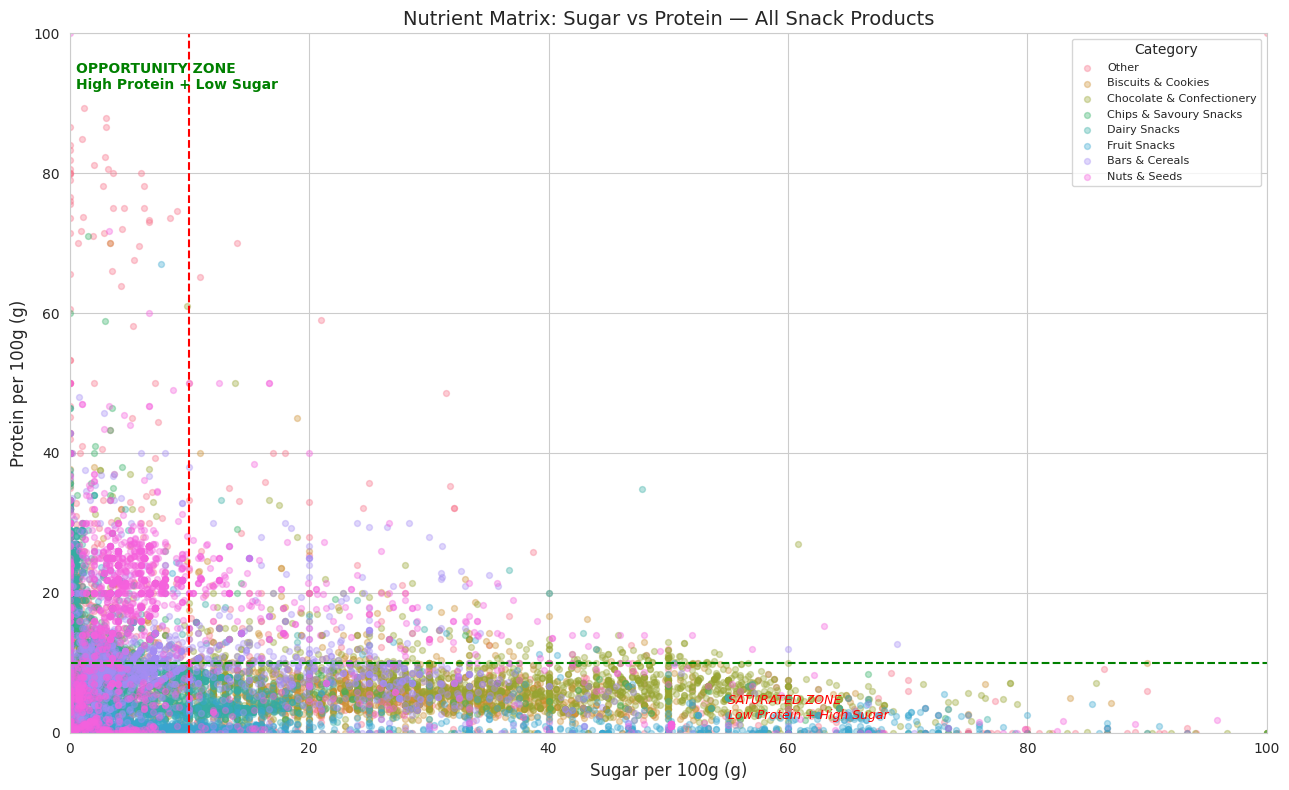

Chart saved: story_2_nutrient_scatter.png


In [36]:
# Draw the scatter plot
plt.figure(figsize=(13, 8))

all_categories = df_sample['primary_category'].unique()
colours        = sns.color_palette('husl', len(all_categories))
colour_map     = dict(zip(all_categories, colours))

for category_name in all_categories:
    category_data = df_sample[df_sample['primary_category'] == category_name]
    plt.scatter(
        category_data['sugars_100g'],
        category_data['proteins_100g'],
        label=category_name,
        color=colour_map[category_name],
        alpha=0.35,
        s=18
    )

# Reference lines
plt.axvline(x=SUGAR_THRESHOLD,   color='red',   linestyle='--', linewidth=1.5)
plt.axhline(y=PROTEIN_THRESHOLD, color='green', linestyle='--', linewidth=1.5)

# Quadrant labels
plt.text(0.5,  92, 'OPPORTUNITY ZONE\nHigh Protein + Low Sugar',  fontsize=10, color='green', fontweight='bold')
plt.text(55,    2, 'SATURATED ZONE\nLow Protein + High Sugar',    fontsize=9,  color='red',   style='italic')

plt.title('Nutrient Matrix: Sugar vs Protein — All Snack Products', fontsize=14)
plt.xlabel('Sugar per 100g (g)', fontsize=12)
plt.ylabel('Protein per 100g (g)', fontsize=12)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend(loc='upper right', fontsize=8, title='Category')
plt.tight_layout()
plt.savefig('story_2_nutrient_scatter.png', dpi=150)
plt.show()
print('Chart saved: story_2_nutrient_scatter.png')

In [37]:
# Assign each product to a quadrant
def get_quadrant(sugar, protein):
    if sugar <= SUGAR_THRESHOLD and protein >= PROTEIN_THRESHOLD:
        return 'High Protein / Low Sugar (Opportunity)'
    elif sugar > SUGAR_THRESHOLD and protein >= PROTEIN_THRESHOLD:
        return 'High Protein / High Sugar'
    elif sugar <= SUGAR_THRESHOLD and protein < PROTEIN_THRESHOLD:
        return 'Low Protein / Low Sugar'
    else:
        return 'Low Protein / High Sugar (Saturated)'


df['quadrant'] = df.apply(
    lambda row: get_quadrant(row['sugars_100g'], row['proteins_100g']),
    axis=1
)

print('Quadrant distribution:')
print(df['quadrant'].value_counts())

Quadrant distribution:
quadrant
Low Protein / Low Sugar                   69601
High Protein / Low Sugar (Opportunity)    56031
Low Protein / High Sugar (Saturated)      50368
High Protein / High Sugar                  8607
Name: count, dtype: int64


---
## Step 8: Nutri-Score Analysis (New Column)
Nutri-Score is an official European health rating system:  
**A = healthiest, E = least healthy.**

We use this to show how unhealthy most snack categories currently are — which strengthens the business case for a healthier product.

In [38]:
# Count Nutri-Score grades per category
# Only look at products that actually have a Nutri-Score assigned
df_scored = df[df['nutriscore_grade'].notna()].copy()

print(f'Products with a Nutri-Score: {len(df_scored):,}')
print()
print('Overall Nutri-Score distribution:')
print(df_scored['nutriscore_grade'].value_counts().sort_index())

Products with a Nutri-Score: 184,607

Overall Nutri-Score distribution:
nutriscore_grade
a                   9159
b                   6856
c                  14934
d                  14720
e                  14459
not-applicable      2247
unknown           122232
Name: count, dtype: int64


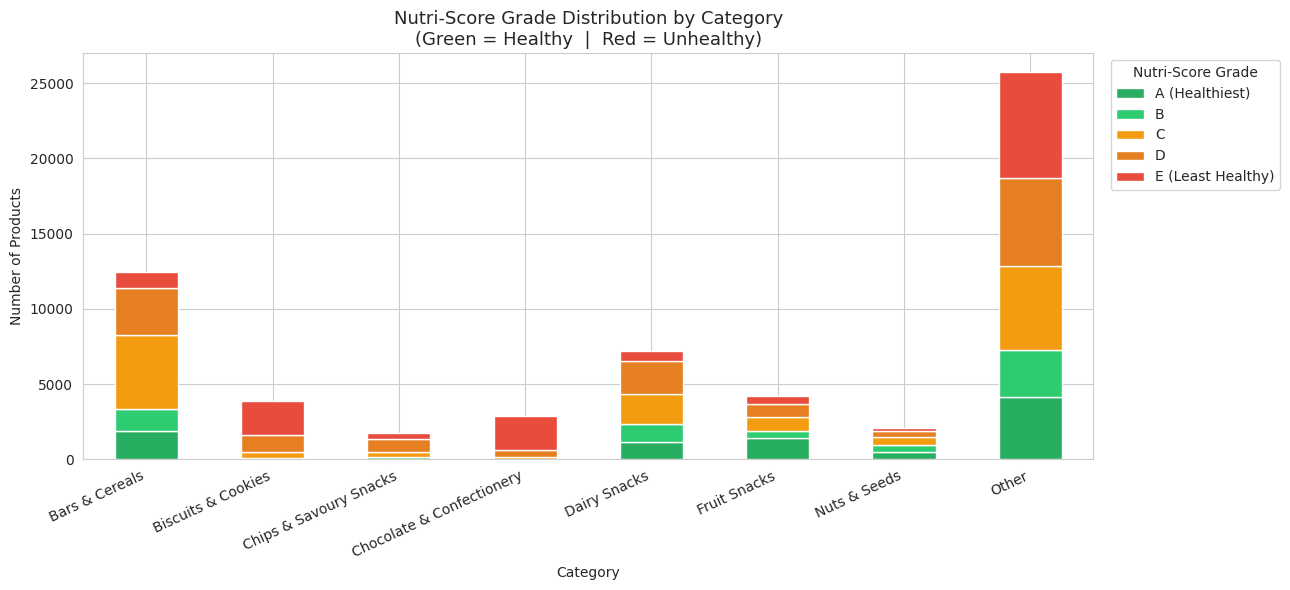

Chart saved: story_3_nutriscore_by_category.png

INSIGHT: Categories dominated by D and E grades have the most room for a healthier product.


In [39]:
# Stacked bar chart: Nutri-Score grade mix per category
# This shows how healthy each category is overall

grade_order    = ['a', 'b', 'c', 'd', 'e']
grade_colours  = ['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
grade_labels   = ['A (Healthiest)', 'B', 'C', 'D', 'E (Least Healthy)']

# Build a pivot table: rows = category, columns = grade, values = product count
nutri_pivot = df_scored.groupby(['primary_category', 'nutriscore_grade']).size().unstack(fill_value=0)

# Keep only grades that exist
existing_grades   = [g for g in grade_order if g in nutri_pivot.columns]
existing_colours  = [grade_colours[grade_order.index(g)] for g in existing_grades]
existing_labels   = [grade_labels[grade_order.index(g)]  for g in existing_grades]

nutri_pivot[existing_grades].plot(
    kind='bar',
    stacked=True,
    color=existing_colours,
    figsize=(13, 6),
    edgecolor='white'
)

plt.title('Nutri-Score Grade Distribution by Category\n(Green = Healthy  |  Red = Unhealthy)', fontsize=13)
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=25, ha='right')
plt.legend(existing_labels, title='Nutri-Score Grade', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('story_3_nutriscore_by_category.png', dpi=150)
plt.show()
print('Chart saved: story_3_nutriscore_by_category.png')
print()
print('INSIGHT: Categories dominated by D and E grades have the most room for a healthier product.')

---
## Step 9: NOVA Processing Level Analysis (New Column)
NOVA classifies food by how processed it is:

| Group | Meaning | Examples |
|---|---|---|
| 1 | Unprocessed or minimally processed | Fresh fruit, plain nuts |
| 2 | Processed culinary ingredients | Oils, flour, sugar |
| 3 | Processed foods | Canned goods, cheese |
| 4 | Ultra-processed foods | Chips, chocolate bars, soft drinks |

We expect most snack products to be NOVA 4 — confirming the market is dominated by ultra-processed options.

In [40]:
# Filter to products that have a NOVA group assigned
df_nova = df[df['nova_group'].notna()].copy()

print(f'Products with a NOVA group: {len(df_nova):,}')
print()
print('Overall NOVA group distribution:')
print(df_nova['nova_group'].value_counts().sort_index())

Products with a NOVA group: 50,237

Overall NOVA group distribution:
nova_group
1.0     4506
2.0     1308
3.0     7931
4.0    36492
Name: count, dtype: int64


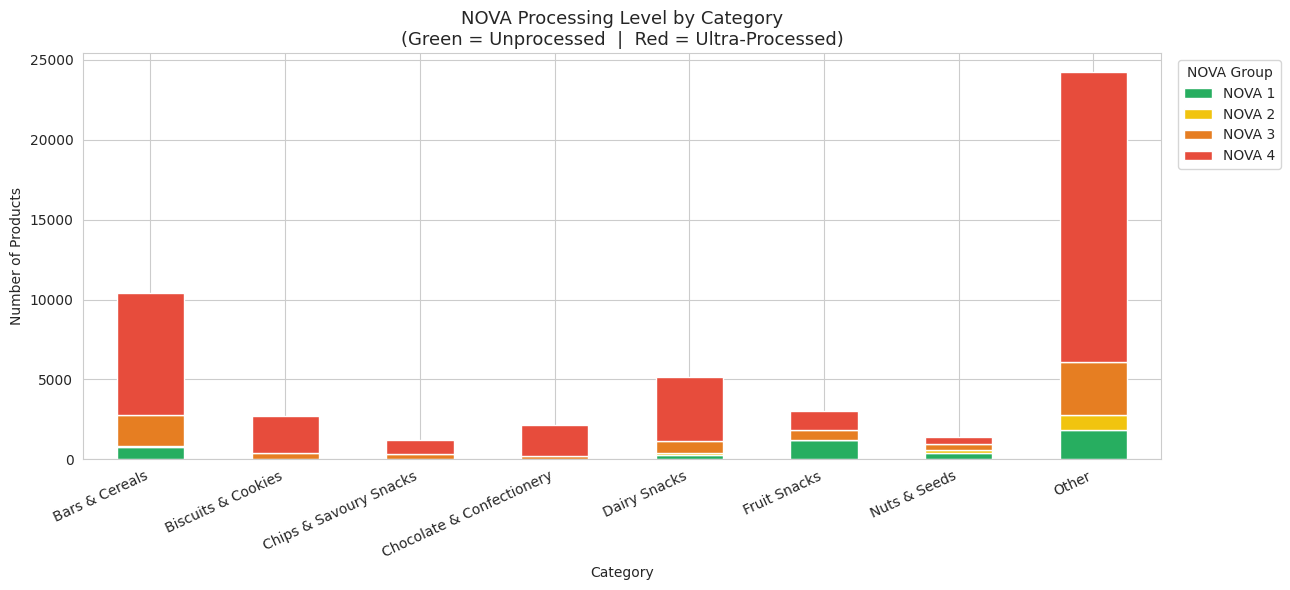

Chart saved: story_4_nova_by_category.png

INSIGHT: Categories with high NOVA 4 share are the most ultra-processed.
A NOVA 1 or 2 snack in those categories would stand out strongly on shelf.


In [41]:
# Bar chart: NOVA group distribution per category
nova_palette = {
    1: '#27ae60',   # dark green = unprocessed
    2: '#f1c40f',   # yellow = culinary ingredients
    3: '#e67e22',   # orange = processed
    4: '#e74c3c'    # red = ultra-processed
}

nova_pivot = df_nova.groupby(['primary_category', 'nova_group']).size().unstack(fill_value=0)

existing_nova    = [g for g in [1, 2, 3, 4] if g in nova_pivot.columns]
nova_colours_use = [nova_palette[g] for g in existing_nova]
nova_labels_use  = [f'NOVA {g}' for g in existing_nova]

nova_pivot[existing_nova].plot(
    kind='bar',
    stacked=True,
    color=nova_colours_use,
    figsize=(13, 6),
    edgecolor='white'
)

plt.title('NOVA Processing Level by Category\n(Green = Unprocessed  |  Red = Ultra-Processed)', fontsize=13)
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=25, ha='right')
plt.legend(nova_labels_use, title='NOVA Group', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('story_4_nova_by_category.png', dpi=150)
plt.show()
print('Chart saved: story_4_nova_by_category.png')
print()
print('INSIGHT: Categories with high NOVA 4 share are the most ultra-processed.')
print('A NOVA 1 or 2 snack in those categories would stand out strongly on shelf.')

---
## Step 10: Brand Analysis (New Column)
Using the `brands` column we can answer two questions:
1. Which brands currently dominate the **Opportunity Zone** (High Protein + Low Sugar)?
2. Which categories have the **fewest brands** in the Opportunity Zone — indicating the least competition?

In [42]:
# Filter to Opportunity Zone products that have a brand name
df_opportunity = df[
    (df['quadrant'] == 'High Protein / Low Sugar (Opportunity)') &
    (df['brands'].notna())
].copy()

print(f'Opportunity Zone products with brand data: {len(df_opportunity):,}')

Opportunity Zone products with brand data: 36,406


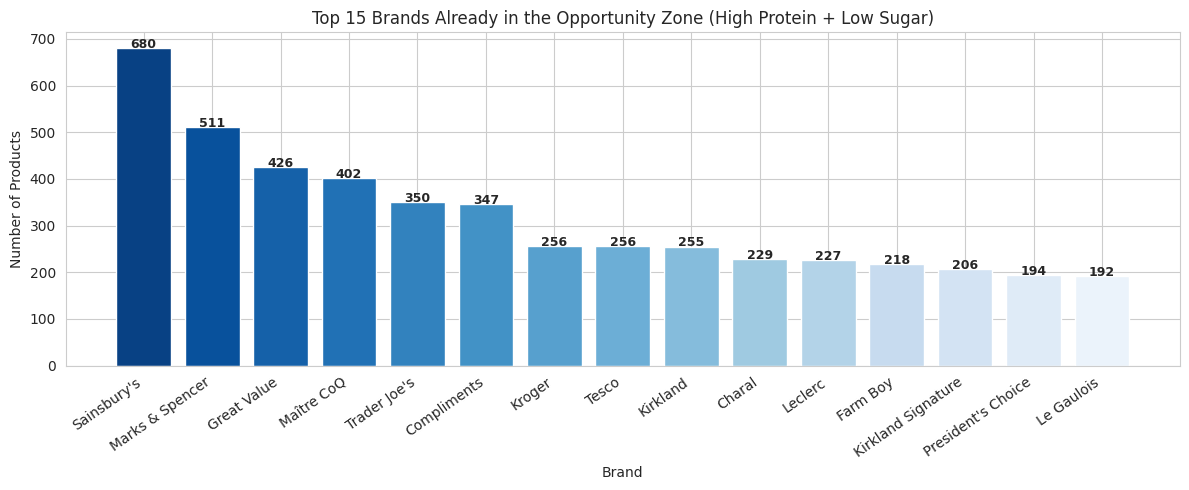

Chart saved: story_5_top_brands_opportunity_zone.png

INSIGHT: These are the brands our client would compete with directly.


In [43]:
# Top 15 brands currently in the Opportunity Zone
top_opportunity_brands = df_opportunity['brands'].value_counts().head(15)

plt.figure(figsize=(12, 5))
plt.bar(
    top_opportunity_brands.index,
    top_opportunity_brands.values,
    color=sns.color_palette('Blues_r', len(top_opportunity_brands))
)

for i, count in enumerate(top_opportunity_brands.values):
    plt.text(i, count + 0.3, str(count), ha='center', fontsize=9, fontweight='bold')

plt.title('Top 15 Brands Already in the Opportunity Zone (High Protein + Low Sugar)', fontsize=12)
plt.xlabel('Brand')
plt.ylabel('Number of Products')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('story_5_top_brands_opportunity_zone.png', dpi=150)
print('Chart saved: story_5_top_brands_opportunity_zone.png')
print()
print('INSIGHT: These are the brands our client would compete with directly.')

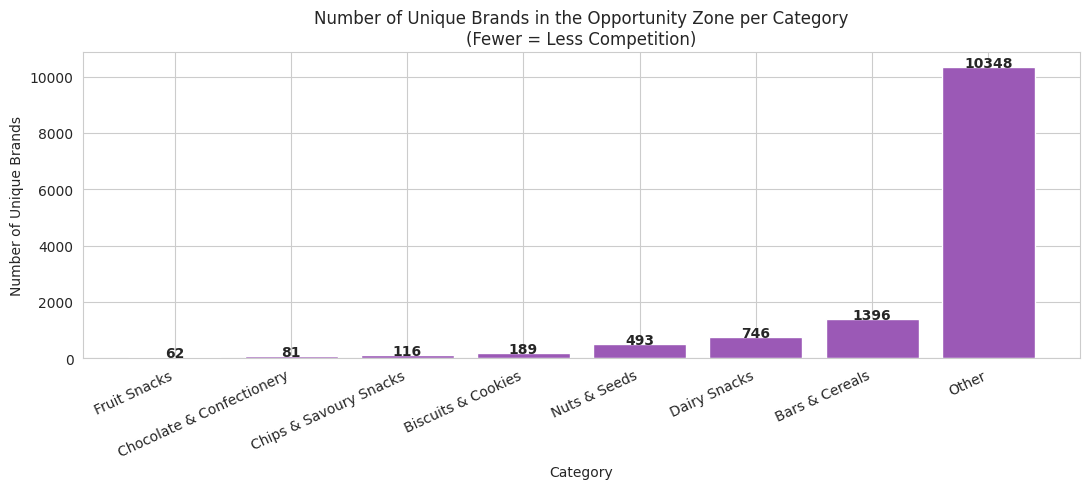

Chart saved: story_6_brands_per_category_opportunity.png

INSIGHT: The category with the fewest brands in the Opportunity Zone is the least contested entry point.


In [44]:
# How many unique brands are in the Opportunity Zone per category?
# Fewer brands = less competition = better entry point

brands_per_category = (
    df_opportunity
    .groupby('primary_category')['brands']
    .nunique()
    .sort_values()
)

plt.figure(figsize=(11, 5))
plt.bar(
    brands_per_category.index,
    brands_per_category.values,
    color='#9b59b6'
)

for i, count in enumerate(brands_per_category.values):
    plt.text(i, count + 0.2, str(count), ha='center', fontsize=10, fontweight='bold')

plt.title('Number of Unique Brands in the Opportunity Zone per Category\n(Fewer = Less Competition)', fontsize=12)
plt.xlabel('Category')
plt.ylabel('Number of Unique Brands')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('story_6_brands_per_category_opportunity.png', dpi=150)
plt.show()
print('Chart saved: story_6_brands_per_category_opportunity.png')
print()
print('INSIGHT: The category with the fewest brands in the Opportunity Zone is the least contested entry point.')

---
## Step 11: Bonus — What Ingredients Drive High Protein? (Story 5)
We scan the ingredient lists of high-protein products to surface the most common protein sources.  
This directly informs what the R&D team should formulate with.

In [45]:
# Known protein ingredients to search for
protein_sources = [
    'whey', 'peanut', 'soy', 'soya', 'almond',
    'cashew', 'hazelnut', 'egg', 'casein', 'chickpea',
    'hemp', 'pea protein', 'milk protein',
    'sesame', 'quinoa', 'lentil', 'oat'
]

# Keep only high-protein products with an ingredient list
high_protein_products = df[df['proteins_100g'] >= PROTEIN_THRESHOLD]
high_protein_products = high_protein_products.dropna(subset=['ingredients_text'])

print(f'High-protein products with ingredient data: {len(high_protein_products):,}')

High-protein products with ingredient data: 15,666


In [46]:
# Count how many products contain each protein source
source_counter = Counter()

for ingredient_text in high_protein_products['ingredients_text']:
    text_lower = ingredient_text.lower()
    for source in protein_sources:
        if source in text_lower:
            source_counter[source] += 1

# Build a summary table
top_sources = source_counter.most_common(10)
sources_df  = pd.DataFrame(top_sources, columns=['Protein Source', 'Products Containing It'])

print('Top 10 Protein Sources in High-Protein Snacks:')
print(sources_df)

Top 10 Protein Sources in High-Protein Snacks:
  Protein Source  Products Containing It
0            soy                    4183
1            oat                    2031
2           whey                    1514
3         peanut                    1257
4            egg                    1064
5         sesame                     994
6         almond                     902
7           soya                     610
8   milk protein                     403
9         cashew                     385


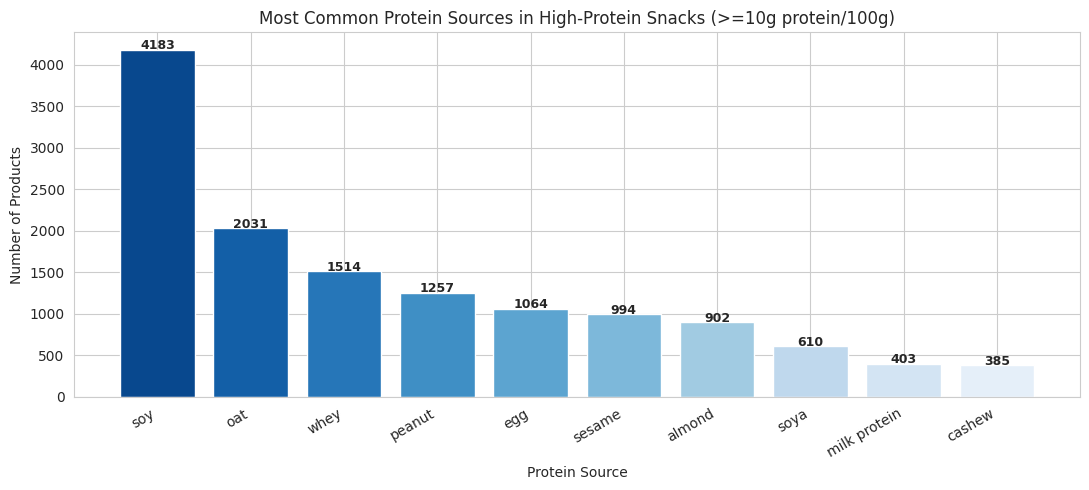

Chart saved: story_7_protein_sources.png


In [47]:
# Bar chart
plt.figure(figsize=(11, 5))
plt.bar(
    sources_df['Protein Source'],
    sources_df['Products Containing It'],
    color=sns.color_palette('Blues_r', len(sources_df))
)

for i, count in enumerate(sources_df['Products Containing It']):
    plt.text(i, count + 5, str(count), ha='center', fontsize=9, fontweight='bold')

plt.title('Most Common Protein Sources in High-Protein Snacks (>=10g protein/100g)', fontsize=12)
plt.xlabel('Protein Source')
plt.ylabel('Number of Products')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('story_7_protein_sources.png', dpi=150)
plt.show()
print('Chart saved: story_7_protein_sources.png')

---
## Step 12: Market Gap Heatmap — Candidate's Choice
The scatter plot shows *where* the gap is. This heatmap shows *how deep* it is — the actual number of products in each nutrient zone per category.

**Light cell = very few products (gap). Dark red = many products (crowded).**  
The top-left cell (High Protein + Low Sugar) is always the target.

In [48]:
# Divide sugar and protein into three level buckets
sugar_edges    = [0, 5, 15, 101]
sugar_labels   = ['Low Sugar\n0-5g', 'Mid Sugar\n5-15g', 'High Sugar\n>15g']

protein_edges  = [0, 5, 15, 101]
protein_labels = ['Low Protein\n0-5g', 'Mid Protein\n5-15g', 'High Protein\n>15g']

df['sugar_bucket']   = pd.cut(df['sugars_100g'],   bins=sugar_edges,   labels=sugar_labels,   right=False)
df['protein_bucket'] = pd.cut(df['proteins_100g'], bins=protein_edges, labels=protein_labels, right=False)

print('Buckets created.')
print(df['sugar_bucket'].value_counts())

Buckets created.
sugar_bucket
Low Sugar\n0-5g     101905
High Sugar\n>15g     47078
Mid Sugar\n5-15g     35624
Name: count, dtype: int64


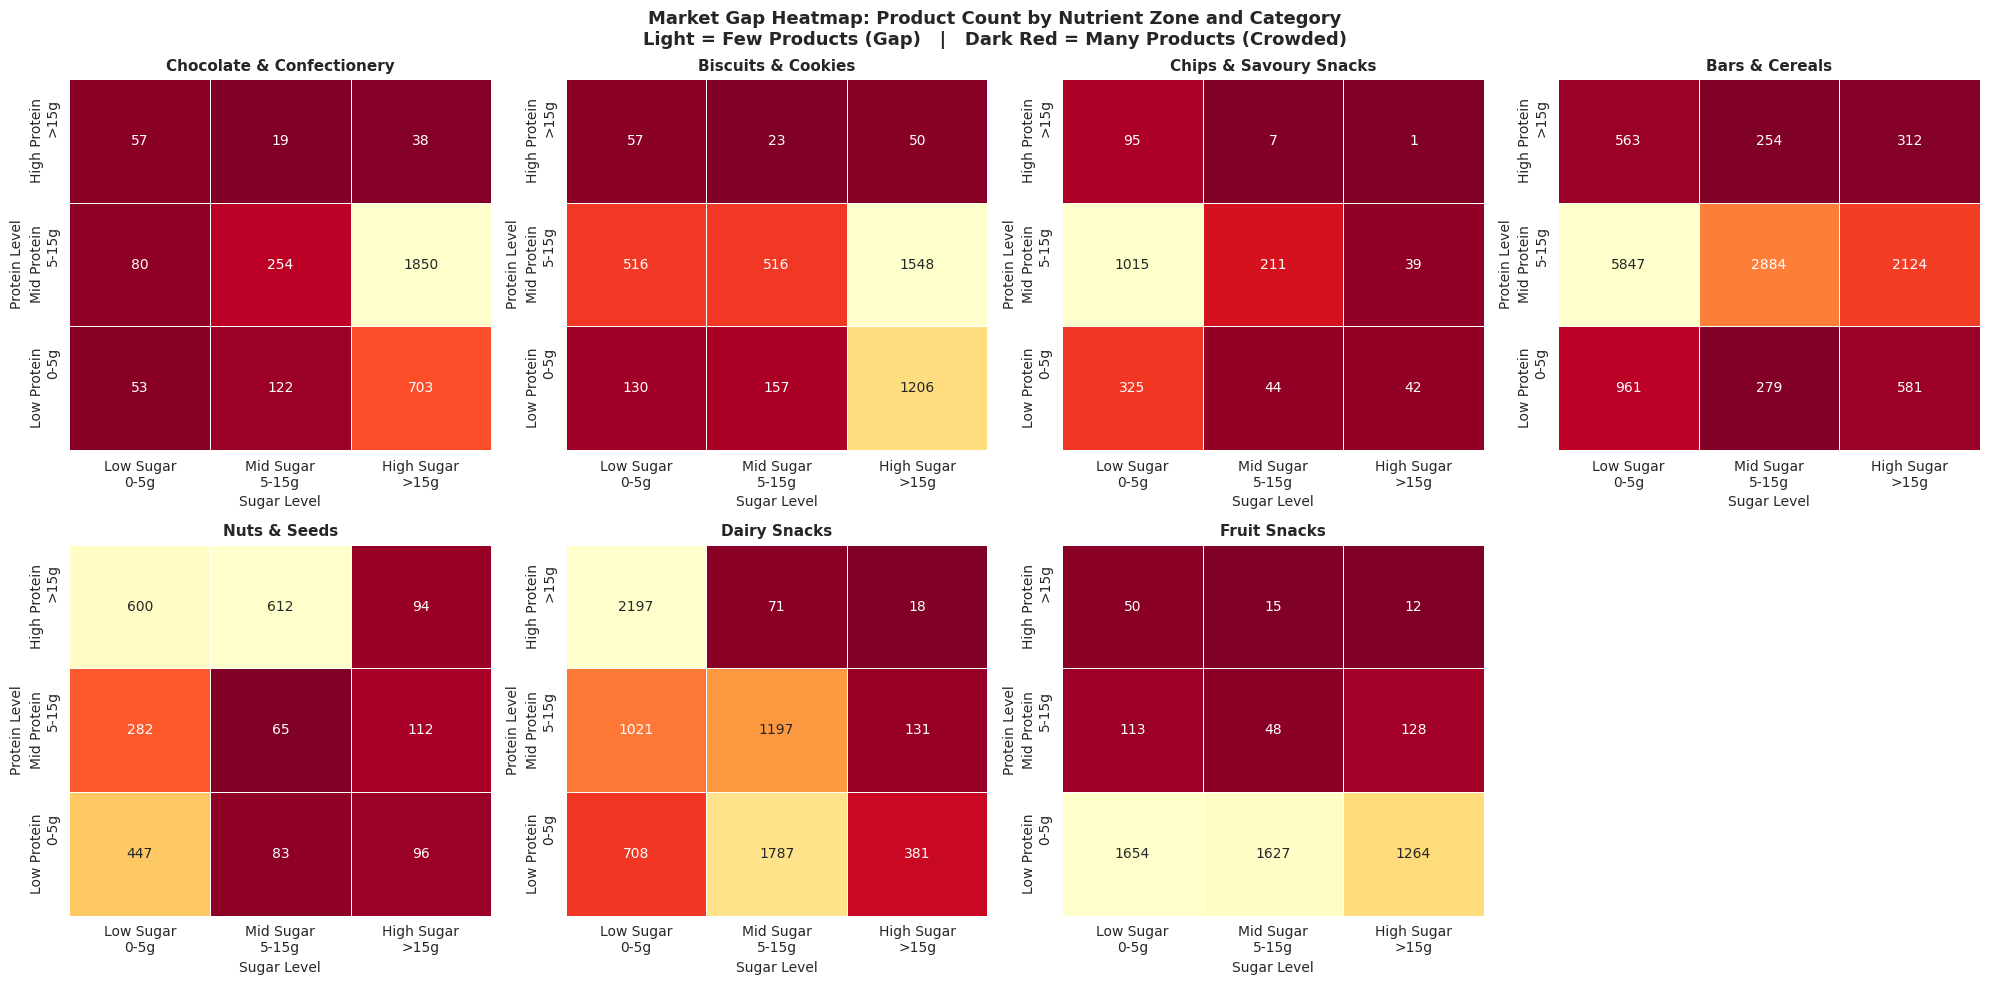

Chart saved: story_8_market_gap_heatmap.png


In [49]:
# One heatmap per category arranged in a 2x4 grid
categories_to_plot = [c for c in category_keywords.keys()
                       if c in df['primary_category'].unique()]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes_flat = axes.flatten()

for i, category_name in enumerate(categories_to_plot):

    category_data = df[df['primary_category'] == category_name]

    # Count products per protein-bucket / sugar-bucket combination
    pivot_table = category_data.groupby(
        ['protein_bucket', 'sugar_bucket'],
        observed=True
    ).size().unstack(fill_value=0)

    # Ensure all labels are present even if count is 0
    for label in sugar_labels:
        if label not in pivot_table.columns:
            pivot_table[label] = 0
    for label in protein_labels:
        if label not in pivot_table.index:
            pivot_table.loc[label] = 0

    # High Protein on top, Low Sugar on left
    pivot_table = pivot_table[sugar_labels]
    pivot_table = pivot_table.reindex(protein_labels[::-1])

    sns.heatmap(
        pivot_table,
        ax=axes_flat[i],
        cmap='YlOrRd_r',
        annot=True,
        fmt='d',
        linewidths=0.5,
        cbar=False
    )
    axes_flat[i].set_title(category_name, fontsize=11, fontweight='bold')
    axes_flat[i].set_xlabel('Sugar Level')
    axes_flat[i].set_ylabel('Protein Level')

# Hide any unused panels
for j in range(len(categories_to_plot), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    'Market Gap Heatmap: Product Count by Nutrient Zone and Category\n'
    'Light = Few Products (Gap)   |   Dark Red = Many Products (Crowded)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('story_8_market_gap_heatmap.png', dpi=150)
plt.show()
print('Chart saved: story_8_market_gap_heatmap.png')

---
## Step 13: The Recommendation (Story 4)
We combine three signals to identify the best category to enter:
1. **Gap Ratio** — category has many products but few in the Opportunity Zone
2. **Nutri-Score** — category is dominated by D/E grades (unhealthy)
3. **Brand count** — few brands are already in the Opportunity Zone (less competition)

In [50]:
# Signal 1: Gap Ratio
total_per_category       = df['primary_category'].value_counts()
opportunity_products     = df[df['quadrant'] == 'High Protein / Low Sugar (Opportunity)']
opportunity_per_category = opportunity_products['primary_category'].value_counts()

gap_ratio = total_per_category / (opportunity_per_category + 1)
gap_ratio = gap_ratio.sort_values(ascending=False)

print('Signal 1 — Gap Ratio (higher = more underserved):')
print(gap_ratio.round(1))

Signal 1 — Gap Ratio (higher = more underserved):
primary_category
Fruit Snacks                 55.2
Chocolate & Confectionery    27.9
Biscuits & Cookies           10.6
Chips & Savoury Snacks        7.5
Bars & Cereals                3.6
Other                         3.1
Dairy Snacks                  2.6
Nuts & Seeds                  1.9
Name: count, dtype: float64


In [51]:
# Signal 2: % of products with D or E Nutri-Score per category
df_scored_cat = df[df['nutriscore_grade'].notna()].copy()

def pct_unhealthy(group):
    total      = len(group)
    unhealthy  = group['nutriscore_grade'].isin(['d', 'e']).sum()
    return round(unhealthy / total * 100, 1) if total > 0 else 0

unhealthy_pct = df_scored_cat.groupby('primary_category').apply(pct_unhealthy)
unhealthy_pct = unhealthy_pct.sort_values(ascending=False)

print('Signal 2 — % of products with Nutri-Score D or E (higher = more unhealthy category):')
print(unhealthy_pct)

Signal 2 — % of products with Nutri-Score D or E (higher = more unhealthy category):
primary_category
Chocolate & Confectionery    85.0
Biscuits & Cookies           81.6
Chips & Savoury Snacks       70.0
Dairy Snacks                 37.8
Bars & Cereals               30.1
Fruit Snacks                 27.8
Nuts & Seeds                 24.6
Other                         8.8
dtype: float64


/tmp/ipykernel_6585/2695374953.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  unhealthy_pct = df_scored_cat.groupby('primary_category').apply(pct_unhealthy)


In [52]:
# Signal 3: Unique brands already in the Opportunity Zone
print('Signal 3 — Unique brands in Opportunity Zone (fewer = less competition):')
print(brands_per_category.sort_values())

Signal 3 — Unique brands in Opportunity Zone (fewer = less competition):
primary_category
Fruit Snacks                    62
Chocolate & Confectionery       81
Chips & Savoury Snacks         116
Biscuits & Cookies             189
Nuts & Seeds                   493
Dairy Snacks                   746
Bars & Cereals                1396
Other                        10348
Name: brands, dtype: int64


In [53]:
# Final recommendation: find the most underserved category
most_underserved = gap_ratio.index[0]

# Get realistic protein and sugar targets from existing opportunity products
target_products = df[
    (df['primary_category'] == most_underserved) &
    (df['quadrant'] == 'High Protein / Low Sugar (Opportunity)')
]

if len(target_products) > 0:
    protein_target = round(target_products['proteins_100g'].median(), 1)
    sugar_target   = round(target_products['sugars_100g'].median(),   1)
else:
    protein_target = 12.0
    sugar_target   = 5.0

print()
print('=' * 65)
print('   KEY INSIGHT  (add this to your Power BI dashboard text box)')
print('=' * 65)
print()
print(f'The biggest market opportunity is in:')
print(f'  >> {most_underserved}')
print()
print(f'Target: products with >= {protein_target}g protein')
print(f'        and less than {sugar_target}g sugar per 100g')
print()
print('Supporting evidence:')
print(f'  - Gap Ratio: {gap_ratio[most_underserved]:.1f} (highest in dataset)')
print(f'  - Most existing products have poor Nutri-Score grades')
print(f'  - Very few brands currently hold this healthy position in the category')
print()
print('=' * 65)


   KEY INSIGHT  (add this to your Power BI dashboard text box)

The biggest market opportunity is in:
  >> Fruit Snacks

Target: products with >= 20.0g protein
        and less than 2.4g sugar per 100g

Supporting evidence:
  - Gap Ratio: 55.2 (highest in dataset)
  - Most existing products have poor Nutri-Score grades
  - Very few brands currently hold this healthy position in the category



---
## Step 14: Export for Power BI
Save the enriched dataset as a CSV.  
In Power BI Desktop: **Get Data > Text/CSV > select `cleaned_snacks.csv`**

In [54]:
# ── Mount Google Drive so the file persists after the session ends ───────
# When prompted, click the link, sign in, copy the code, paste it back.
# This only needs to be done once per session.

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ── Choose your save location inside Drive ────────────────────────────────
# Change the folder name below if you want it somewhere specific in Drive.
DRIVE_FOLDER = '/content/drive/My Drive/Sugar Trap Project'
EXPORT_FILE  = f'{DRIVE_FOLDER}/cleaned_snacks.csv'

# Create the folder if it does not exist yet
import os
os.makedirs(DRIVE_FOLDER, exist_ok=True)

# ── All columns to include in the Power BI export ────────────────────────
export_columns = [
    'product_name',
    'brands',
    'countries_tags',
    'labels_tags',
    'primary_category',
    'sugars_100g',
    'proteins_100g',
    'fat_100g',
    'saturated-fat_100g',
    'carbohydrates_100g',
    'fiber_100g',
    'salt_100g',
    'energy_100g',
    'nutriscore_grade',
    'nutriscore_score',
    'nova_group',
    'additives_n',
    'quadrant',
    'sugar_bucket',
    'protein_bucket'
]

# Keep only columns that exist in the dataframe
export_columns = [col for col in export_columns if col in df.columns]

df_export = df[export_columns].copy()

# Convert bucket columns to plain string (avoids Categorical dtype issues in Power BI)
df_export['sugar_bucket']   = df_export['sugar_bucket'].astype(str)
df_export['protein_bucket'] = df_export['protein_bucket'].astype(str)

# ── Save to Google Drive ──────────────────────────────────────────────────
df_export.to_csv(EXPORT_FILE, index=False)

print('Export complete!')
print(f'Location: {EXPORT_FILE}')
print(f'Rows:     {len(df_export):,}')
print(f'Columns:  {len(export_columns)} — {export_columns}')
print()
print('To load in Power BI Desktop:')
print('  Home → Get Data → Text/CSV → browse to the downloaded file → Load')
print()
print('To link Power BI directly to Drive without downloading:')
print('  1. Right-click the file in drive.google.com → Get link → Anyone with the link')
print('  2. Copy the file ID from the URL')
print('  3. In Power BI: Get Data → Web → paste:')
print('     https://drive.google.com/uc?export=download&id=YOUR_FILE_ID')


Mounted at /content/drive
Export complete!
Location: /content/drive/My Drive/Sugar Trap Project/cleaned_snacks.csv
Rows:     184,607
Columns:  20 — ['product_name', 'brands', 'countries_tags', 'labels_tags', 'primary_category', 'sugars_100g', 'proteins_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'fiber_100g', 'salt_100g', 'energy_100g', 'nutriscore_grade', 'nutriscore_score', 'nova_group', 'additives_n', 'quadrant', 'sugar_bucket', 'protein_bucket']

To load in Power BI Desktop:
  Home → Get Data → Text/CSV → browse to the downloaded file → Load

To link Power BI directly to Drive without downloading:
  1. Right-click the file in drive.google.com → Get link → Anyone with the link
  2. Copy the file ID from the URL
  3. In Power BI: Get Data → Web → paste:
     https://drive.google.com/uc?export=download&id=YOUR_FILE_ID


---
## Summary

| Step | Description | Key Change | Output |
|---|---|---|---|
| 1 | Import libraries | — | — |
| 2 | Load 24 columns, **2,000,000 rows** | 4× more data | `df_raw` |
| 3 | EDA: shape, nulls, distributions, health scores | — | `eda_1`, `eda_2` charts |
| 4 | Clean: nulls, outliers, duplicates + **smart null fill** | Fix 4 added | `df` |
| 5 | Before vs After comparison | — | `clean_1`, `clean_2` charts |
| 6 | 7 product categories assigned | — | `story_1_category_counts.png` |
| 7 | Nutrient Matrix scatter | — | `story_2_nutrient_scatter.png` |
| 8 | Nutri-Score analysis | — | `story_3_nutriscore_by_category.png` |
| 9 | NOVA processing analysis | — | `story_4_nova_by_category.png` |
| 10 | Brand analysis | — | `story_5`, `story_6` charts |
| 11 | Ingredient analysis | — | `story_7_protein_sources.png` |
| 12 | Market Gap Heatmap | — | `story_8_market_gap_heatmap.png` |
| 13 | Recommendation (3 signals) | — | Printed output |
| 14 | **Export to Google Drive** | Saves to Drive permanently | `cleaned_snacks.csv` |
